In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
import numpy as np
import os
import shutil
import json
from PIL import Image, ImageDraw
from google.colab import drive

# 1. SETUP & MOUNT
drive.mount('/content/drive')
KAGGLE_CORN_PATH = "/content/drive/My Drive/Corn_Dataset"
DATA_DIR = "/content/FINAL_HYBRID_DATASET"
MODEL_SAVE_PATH = "/content/drive/My Drive/Agri_Project_Models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# 2. PREPARE DATASET (Clean Slate)
print("🔄 Setting up Master Dataset...")
if os.path.exists(DATA_DIR): shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR, exist_ok=True)

# A. COPY REAL CORN DATA
print("   🌽 Copying Real Corn Images...")
if os.path.exists(KAGGLE_CORN_PATH):
    for folder in os.listdir(KAGGLE_CORN_PATH):
        src = os.path.join(KAGGLE_CORN_PATH, folder)
        if os.path.isdir(src):
            clean_name = folder.replace("Corn_", "").replace("Maize_", "").strip()
            # Only copy relevant corn classes
            if any(x in clean_name.lower() for x in ['healthy', 'rust', 'gray', 'blight', 'spot']):
                dst = os.path.join(DATA_DIR, clean_name)
                shutil.copytree(src, dst)
else:
    print("❌ ERROR: Corn_Dataset not found in Drive!")

# B. GENERATE BALANCED WEEDS (800 Images per class)
print("   🌱 Generating Balanced Weeds (800 per type)...")

def create_weed(path, type_w):
    img = Image.new('RGB', (224, 224), (255, 255, 255))
    draw = ImageDraw.Draw(img)
    for _ in range(400): draw.point((np.random.randint(0,224), np.random.randint(0,224)), fill=(139,69,19))

    if type_w == "grassy":
        for _ in range(80): # Dense grass
            x = np.random.randint(40, 180)
            draw.line([(x, 224), (x+np.random.randint(-30,30), np.random.randint(50, 180))], fill=(34,139,34), width=3)
    else:
        for _ in range(40): # Dense leaves
            x, y = np.random.randint(30, 190), np.random.randint(30, 190)
            draw.ellipse([x, y, x+50, y+50], fill=(0,100,0))
    img.save(path)

for weed_type in ['Weed_Grassy', 'Weed_Broadleaf']:
    w_path = os.path.join(DATA_DIR, weed_type)
    os.makedirs(w_path, exist_ok=True)
    for i in range(800): # Target 800 images
        create_weed(os.path.join(w_path, f"weed_{i}.jpg"), "grassy" if "Grassy" in weed_type else "broad")

# 3. TRAIN WITH CLASS WEIGHTS
print("🧠 Training with Class Weights...")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training'
)
val_gen = train_datagen.flow_from_directory(
    DATA_DIR, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation'
)

# Calculate Weights to fix imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
weights_dict = dict(enumerate(class_weights))
print(f"⚖️ Weights Applied: {weights_dict}")

# Build & Train Model
base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base.trainable = True

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
preds = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base.input, outputs=preds)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    class_weight=weights_dict, # Key fix
    verbose=1
)

# Save
model.save(os.path.join(MODEL_SAVE_PATH, 'hybrid_corn_weed_model_v2.h5'))
with open(os.path.join(MODEL_SAVE_PATH, 'class_indices.json'), 'w') as f:
    json.dump(train_gen.class_indices, f)

print("✅ DONE: Dataset Balanced & Model Trained (v2)!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Setting up Master Dataset...
   🌽 Copying Real Corn Images...
   🌱 Generating Balanced Weeds (800 per type)...
🧠 Training with Class Weights...
Found 4632 images belonging to 6 classes.
Found 1156 images belonging to 6 classes.
⚖️ Weights Applied: {0: np.float64(0.8418756815703381), 1: np.float64(0.738755980861244), 2: np.float64(1.6782608695652175), 3: np.float64(0.8301075268817204), 4: np.float64(1.20625), 5: np.float64(1.20625)}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1738s 12s/step - accuracy: 0.6567 - loss: 0.9608 - val_accuracy: 0.1384 - val_loss: 1.8353
Epoch 2/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1669s 11s/step - accuracy: 0.9168 - loss: 0.2323 - val_accuracy: 0.3382 - val_loss: 1.7502
Epoch 3/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1649s 11s/step - accuracy: 0.9364 - loss: 0.1637 - val_accuracy: 0.3919 - val_loss: 2.0255
Epoch 4/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1631s 11s/step - accuracy: 0.9556 - loss: 0.1297 - val_accuracy: 0.4654 - val_loss: 1.9274
Epoch 5/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1646s 11s/step - accuracy: 0.9526 - loss: 0.1296 - val_accuracy: 0.8330 - val_loss: 0.5912
Epoch 6/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1627s 11s/step - accuracy: 0.9603 - loss: 0.1096 - val_accuracy: 0.2742 - val_loss: 2.1743
Epoch 7/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1647s 11s/step - accuracy: 0.9743 - loss: 0.0719 - val_accuracy: 0.2647 - val_loss: 23.7204
Epoch 8/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1587s 11s/step - accuracy: 0.9733 - loss: 

✅ DONE: Dataset Balanced & Model Trained (v2)!


In [ ]:
import os
import shutil

# 1. Define paths
source_dir = "/content/temp_weeds/agri_data/data"
dest_dir = "/content/drive/My Drive/Agri_Project_Data/Weed_Broadleaf"

# 2. Make sure destination exists
os.makedirs(dest_dir, exist_ok=True)

# 3. Move images
print(f"🚀 Moving images from {source_dir} to {dest_dir}...")

count = 0
limit = 200  # We only need 200 images for good training

for filename in os.listdir(source_dir):
    if filename.lower().endswith(('.jpeg', '.jpg', '.png')):
        # Construct full file paths
        src_path = os.path.join(source_dir, filename)
        dst_path = os.path.join(dest_dir, filename)

        # Copy the file
        shutil.copy(src_path, dst_path)
        count += 1

        if count >= limit:
            break

print(f"✅ Success! Moved {count} weed images to your Drive.")
print("👉 You can now proceed to training.")

🚀 Moving images from /content/temp_weeds/agri_data/data to /content/drive/My Drive/Agri_Project_Data/Weed_Broadleaf...
✅ Success! Moved 200 weed images to your Drive.
👉 You can now proceed to training.


In [ ]:
import os
import shutil

# 1. Download Corn Data (Fast & Free)
print("🚀 downloading corn data...")
os.system("kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset")
os.system("unzip -q corn-or-maize-leaf-disease-dataset.zip -d /content/temp_corn")

# 2. Move Corn Folders to your Drive
source_root = "/content/temp_corn/data"
dest_root = "/content/drive/My Drive/Agri_Project_Data"

# List of folders we need
corn_classes = ["Blight", "Common_Rust", "Gray_Leaf_Spot", "Healthy"]

print(f"🔄 Merging Corn data into {dest_root}...")

for folder_name in os.listdir(source_root):
    # Check if this folder matches one of our corn classes
    for c in corn_classes:
        if c.lower() in folder_name.lower():
            # Rename it to match your project style (e.g., "Maize_Blight")
            new_name = f"Maize_{c}"
            src = os.path.join(source_root, folder_name)
            dst = os.path.join(dest_root, new_name)

            # Move it
            if not os.path.exists(dst):
                shutil.copytree(src, dst)
                print(f"✅ Restored: {new_name}")
            else:
                print(f"ℹ️ {new_name} is already there.")

print("\n🎉 DONE! You now have Corn AND Weeds in one place.")

🚀 downloading corn data...
🔄 Merging Corn data into /content/drive/My Drive/Agri_Project_Data...
✅ Restored: Maize_Blight
✅ Restored: Maize_Gray_Leaf_Spot
✅ Restored: Maize_Common_Rust
✅ Restored: Maize_Healthy

🎉 DONE! You now have Corn AND Weeds in one place.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import json

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATA_DIR = "/content/drive/My Drive/Agri_Project_Data"

train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'w') as f:
    json.dump(train_generator.class_indices, f)

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

model.save("/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5")

Found 3512 images belonging to 5 classes.
Found 876 images belonging to 5 classes.
Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - accuracy: 0.8299 - loss: 0.5110 - val_accuracy: 0.9212 - val_loss: 0.2424
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 318s 3s/step - accuracy: 0.9422 - loss: 0.1523 - val_accuracy: 0.9498 - val_loss: 0.1438
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - accuracy: 0.9434 - loss: 0.1432 - val_accuracy: 0.9543 - val_loss: 0.1486
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 323s 3s/step - accuracy: 0.9502 - loss: 0.1389 - val_accuracy: 0.9463 - val_loss: 0.1313
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - accuracy: 0.9502 - loss: 0.1357 - val_accuracy: 0.9521 - val_loss: 0.1460
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 318s 3s/step - accuracy: 0.9561 - loss: 0.1263 - val_accuracy: 0.9521 - val_loss: 0.1221
Epoch 7/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 339s 3s/step - accuracy: 0.9714 - loss: 0.0832 - val_accuracy: 0.9441 - val_loss: 0.1626
Epoch 8/15
110

⏳ Loading model from /content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5...


✅ Model Loaded!
📖 Classes the model knows: ['Maize_Blight', 'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Weed_Broadleaf']

👉 Upload a test image now:


Saving corn grass weed.jpg to corn grass weed.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


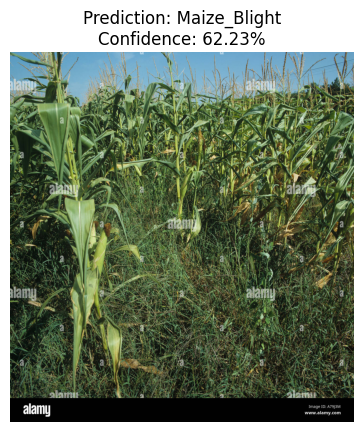

🎯 RESULT: Maize_Blight
📊 Confidence: 62.23%


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files
import json
import matplotlib.pyplot as plt

# 1. Load the Model we just trained
model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
print(f"⏳ Loading model from {model_path}...")
model = tf.keras.models.load_model(model_path)
print("✅ Model Loaded!")

# 2. Load the Class Names (The "dictionary")
class_indices_path = '/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json'
with open(class_indices_path, 'r') as f:
    class_indices = json.load(f)

# Flip the dictionary so numbers point to names: {0: 'Maize_Blight', ...}
class_names = {v: k for k, v in class_indices.items()}
print(f"📖 Classes the model knows: {list(class_names.values())}")

# 3. Upload an Image
print("\n👉 Upload a test image now:")
uploaded = files.upload()

for filename in uploaded.keys():
    # 4. Preprocess the image (Must match Training!)
    img_path = filename
    img = image.load_img(img_path, target_size=(224, 224)) # Force 224x224

    # Convert to array & preprocess
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

    # 5. Make Prediction
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0]) # Get confidence scores

    # 6. Show Result
    predicted_class = class_names[np.argmax(predictions)]
    confidence = 100 * np.max(predictions)

    plt.imshow(image.load_img(img_path)) # Show the image
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.show()

    print(f"🎯 RESULT: {predicted_class}")
    print(f"📊 Confidence: {confidence:.2f}%")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json

# 1. Load the Model
model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")

# 2. Load the Class Names (The 'Memory')
# You need this so the model knows that "0" means "Blight"
with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'r') as f:
    class_indices = json.load(f)
    # Flip it so we can look up names by number
    class_names = {v: k for k, v in class_indices.items()}

print(f"Ready to detect: {list(class_names.values())}")

Mounted at /content/drive


Model loaded successfully!
Ready to detect: ['Maize_Blight', 'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Weed_Broadleaf', 'Weed_Grass']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json

# 1. Load the Model
model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")

# 2. Load the Class Names (The 'Memory')
# You need this so the model knows that "0" means "Blight"
with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'r') as f:
    class_indices = json.load(f)
    # Flip it so we can look up names by number
    class_names = {v: k for k, v in class_indices.items()}

print(f"Ready to detect: {list(class_names.values())}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model loaded successfully!
Ready to detect: ['Maize_Blight', 'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Weed_Broadleaf', 'Weed_Grass']


In [ ]:
import os
import shutil

os.system("kaggle datasets download -d fpeccia/weed-detection-in-soybean-crops")
os.system("unzip -q weed-detection-in-soybean-crops.zip -d /content/temp_grass")

source_grass = "/content/temp_grass/dataset/grass"
dest_grass = "/content/drive/My Drive/Agri_Project_Data/Weed_Grass"

if os.path.exists(source_grass):
    shutil.copytree(source_grass, dest_grass, dirs_exist_ok=True)
    print("Folder moved successfully.")
else:
    for root, dirs, files in os.walk("/content/temp_grass"):
        if 'grass' in dirs:
            src = os.path.join(root, 'grass')
            shutil.copytree(src, dest_grass, dirs_exist_ok=True)
            print("Folder found and moved.")
            break

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import json

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATA_DIR = "/content/drive/My Drive/Agri_Project_Data"

train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'w') as f:
    json.dump(train_generator.class_indices, f)

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

model.save("/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5")

Found 6328 images belonging to 6 classes.
Found 1580 images belonging to 6 classes.
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 2382s 12s/step - accuracy: 0.8759 - loss: 0.3797 - val_accuracy: 0.9696 - val_loss: 0.1019
Epoch 2/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 730s 4s/step - accuracy: 0.9537 - loss: 0.1180 - val_accuracy: 0.9728 - val_loss: 0.0751
Epoch 3/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 753s 4s/step - accuracy: 0.9699 - loss: 0.0888 - val_accuracy: 0.9703 - val_loss: 0.0912
Epoch 4/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 726s 4s/step - accuracy: 0.9710 - loss: 0.0807 - val_accuracy: 0.9715 - val_loss: 0.0816
Epoch 5/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 741s 4s/step - accuracy: 0.9730 - loss: 0.0683 - val_accuracy: 0.9759 - val_loss: 0.0748
Epoch 6/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 737s 4s/step - accuracy: 0.9780 - loss: 0.0606 - val_accuracy: 0.9709 - val_loss: 0.0973
Epoch 7/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 721s 4s/step - accuracy: 0.9764 - loss: 0.0702 - val_accuracy: 0.9671 - val_loss: 0.0889
Epoch 8/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 702s 4s/step - accuracy: 0.9820 - loss: 0.0467 - val_ac

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import json

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATA_DIR = "/content/drive/My Drive/Agri_Project_Data"

train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'w') as f:
    json.dump(train_generator.class_indices, f)

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

model.save("/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5")

Found 6328 images belonging to 6 classes.
Found 1580 images belonging to 6 classes.
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 2382s 12s/step - accuracy: 0.8759 - loss: 0.3797 - val_accuracy: 0.9696 - val_loss: 0.1019
Epoch 2/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 730s 4s/step - accuracy: 0.9537 - loss: 0.1180 - val_accuracy: 0.9728 - val_loss: 0.0751
Epoch 3/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 753s 4s/step - accuracy: 0.9699 - loss: 0.0888 - val_accuracy: 0.9703 - val_loss: 0.0912
Epoch 4/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 726s 4s/step - accuracy: 0.9710 - loss: 0.0807 - val_accuracy: 0.9715 - val_loss: 0.0816
Epoch 5/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 741s 4s/step - accuracy: 0.9730 - loss: 0.0683 - val_accuracy: 0.9759 - val_loss: 0.0748
Epoch 6/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 737s 4s/step - accuracy: 0.9780 - loss: 0.0606 - val_accuracy: 0.9709 - val_loss: 0.0973
Epoch 7/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 721s 4s/step - accuracy: 0.9764 - loss: 0.0702 - val_accuracy: 0.9671 - val_loss: 0.0889
Epoch 8/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 702s 4s/step - accuracy: 0.9820 - loss: 0.0467 - val_ac

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Saving crabgrass.jpg to crabgrass.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


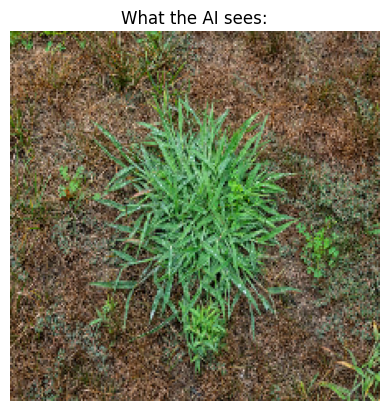


📊 DETAILED SCORECARD:
------------------------------
Maize_Blight: 0.00%
Maize_Common_Rust: 0.00%
Maize_Gray_Leaf_Spot: 0.00%
Maize_Healthy: 0.00%
Weed_Broadleaf: 100.00%
Weed_Grass: 0.00%
------------------------------


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files
import json
import matplotlib.pyplot as plt

# Load Model & Dictionary
model = tf.keras.models.load_model("/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5")
with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'r') as f:
    class_indices = json.load(f)
class_names = {v: k for k, v in class_indices.items()}

# Upload
uploaded = files.upload()

for filename in uploaded.keys():
    img = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

    # Get predictions
    predictions = model.predict(img_array)[0] # Get the raw list of numbers

    # Show the image
    plt.imshow(img)
    plt.axis('off')
    plt.title("What the AI sees:")
    plt.show()

    # PRINT ALL PERCENTAGES
    print("\n📊 DETAILED SCORECARD:")
    print("-" * 30)
    for i, score in enumerate(predictions):
        print(f"{class_names[i]}: {score*100:.2f}%")
    print("-" * 30)

Saving weed in maize.jpg to weed in maize.jpg


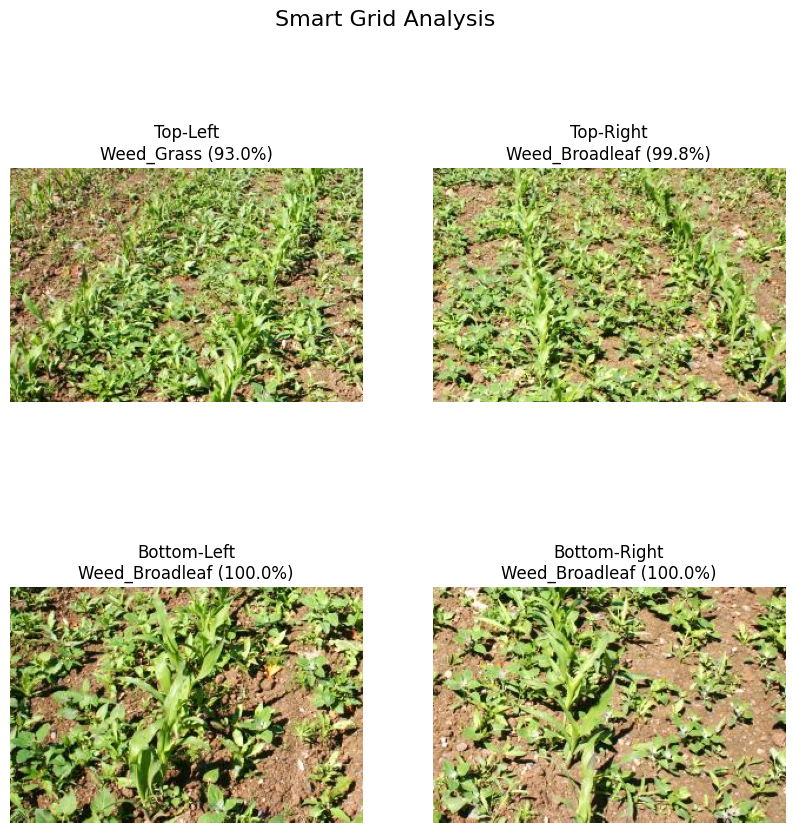


FINAL DIAGNOSIS FOR weed in maize.jpg
DETECTED ISSUES:
  - WEED ALERT: Weed_Broadleaf found.
  - WEED ALERT: Weed_Grass found.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt
import json

model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
model = tf.keras.models.load_model(model_path)

class_indices_path = '/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json'
with open(class_indices_path, 'r') as f:
    class_indices = json.load(f)
class_names = {v: k for k, v in class_indices.items()}

def predict_patch(img_patch):
    img_array = image.img_to_array(img_patch)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100
    return class_names[predicted_index], confidence

uploaded = files.upload()

for filename in uploaded.keys():
    original_img = image.load_img(filename)
    width, height = original_img.size

    crops = {
        "Top-Left": original_img.crop((0, 0, width//2, height//2)),
        "Top-Right": original_img.crop((width//2, 0, width, height//2)),
        "Bottom-Left": original_img.crop((0, height//2, width//2, height)),
        "Bottom-Right": original_img.crop((width//2, height//2, width, height))
    }

    found_problems = set()

    plt.figure(figsize=(10, 10))
    plt.suptitle("Smart Grid Analysis", fontsize=16)

    for i, (position, crop_img) in enumerate(crops.items()):
        crop_resized = crop_img.resize((224, 224))

        label, conf = predict_patch(crop_resized)

        if conf > 70:
            found_problems.add(label)

        plt.subplot(2, 2, i+1)
        plt.imshow(crop_img)
        plt.axis('off')
        plt.title(f"{position}\n{label} ({conf:.1f}%)")

    plt.show()

    print("\n" + "="*40)
    print(f"FINAL DIAGNOSIS FOR {filename}")
    print("="*40)

    if not found_problems:
        print("Everything looks confusing or low confidence.")
    else:
        print("DETECTED ISSUES:")
        for problem in found_problems:
            if "Healthy" in problem:
                print(f"  - Crop is Healthy in parts.")
            elif "Weed" in problem:
                print(f"  - WEED ALERT: {problem} found.")
            else:
                print(f"  - DISEASE ALERT: {problem} found.")

Saving weed in maize.jpg to weed in maize (1).jpg


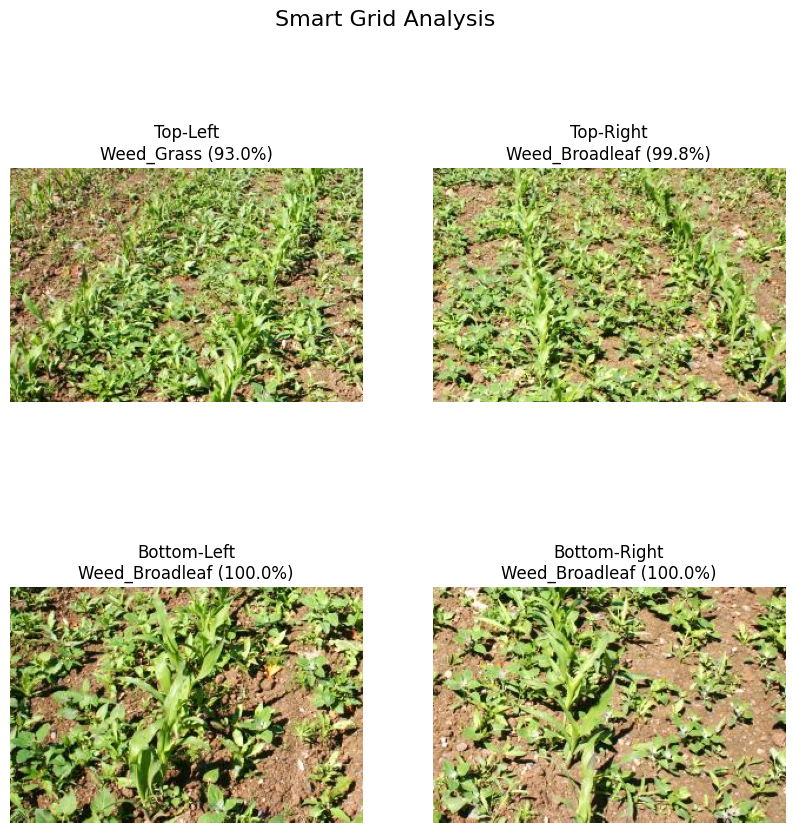


GENERATING EXPERT ADVICE...
----------------------------------------
WEED ALERT: Weed_Broadleaf, Weed_Grass detected.
   - Action: Use a selective herbicide like Nicosulfuron.
   - WARNING: It is raining/humid. Do NOT spray chemicals now.
     Rain washes chemicals away. Wait for dry weather.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt
import json

model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
model = tf.keras.models.load_model(model_path)

class_indices_path = '/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json'
with open(class_indices_path, 'r') as f:
    class_indices = json.load(f)
class_names = {v: k for k, v in class_indices.items()}

weather_report = {
    "temperature": 34,
    "condition": "Rainy",
    "humidity": 85
}

def predict_patch(img_patch):
    img_array = image.img_to_array(img_patch)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100
    return class_names[predicted_index], confidence

def get_expert_advice(vision_results, weather):
    print("\nGENERATING EXPERT ADVICE...")
    print("-" * 40)

    advice = []

    found_weeds = [x for x in vision_results if "Weed" in x]
    found_diseases = [x for x in vision_results if "Maize" in x and "Healthy" not in x]

    if found_weeds:
        advice.append(f"WEED ALERT: {', '.join(set(found_weeds))} detected.")
        advice.append("   - Action: Use a selective herbicide like Nicosulfuron.")

        if weather['condition'] == "Rainy" or weather['humidity'] > 80:
            advice.append("   - WARNING: It is raining/humid. Do NOT spray chemicals now.")
            advice.append("     Rain washes chemicals away. Wait for dry weather.")
        elif weather['temperature'] > 32:
            advice.append("   - WARNING: It is too hot (>32C). Spraying now may burn the crop.")
        else:
            advice.append("   - Weather is good for spraying.")

    if found_diseases:
        advice.append(f"DISEASE ALERT: {', '.join(set(found_diseases))} detected.")
        if weather['condition'] == "Rainy" and weather['humidity'] > 70:
            advice.append("   - CRITICAL: High humidity spreads fungal diseases fast!")
            advice.append("   - Action: Apply Fungicide immediately once rain stops.")
        else:
            advice.append("   - Action: Monitor leaves. If spots expand, apply Fungicide.")

    if not found_weeds and not found_diseases:
        advice.append("CROP STATUS: Healthy. No immediate actions required.")

    return "\n".join(advice)

uploaded = files.upload()

for filename in uploaded.keys():
    original_img = image.load_img(filename)
    width, height = original_img.size

    crops = {
        "Top-Left": original_img.crop((0, 0, width//2, height//2)),
        "Top-Right": original_img.crop((width//2, 0, width, height//2)),
        "Bottom-Left": original_img.crop((0, height//2, width//2, height)),
        "Bottom-Right": original_img.crop((width//2, height//2, width, height))
    }

    found_problems = []

    plt.figure(figsize=(10, 10))
    plt.suptitle("Smart Grid Analysis", fontsize=16)

    for i, (position, crop_img) in enumerate(crops.items()):
        crop_resized = crop_img.resize((224, 224))
        label, conf = predict_patch(crop_resized)

        if conf > 60:
            found_problems.append(label)

        plt.subplot(2, 2, i+1)
        plt.imshow(crop_img)
        plt.axis('off')
        plt.title(f"{position}\n{label} ({conf:.1f}%)")

    plt.show()

    final_report = get_expert_advice(found_problems, weather_report)
    print(final_report)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json

# 1. Load the Model
model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")

# 2. Load the Class Names (The 'Memory')
# You need this so the model knows that "0" means "Blight"
with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'r') as f:
    class_indices = json.load(f)
    # Flip it so we can look up names by number
    class_names = {v: k for k, v in class_indices.items()}

print(f"Ready to detect: {list(class_names.values())}")

Mounted at /content/drive


Model loaded successfully!
Ready to detect: ['Maize_Blight', 'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Weed_Broadleaf', 'Weed_Grass']


Step 1: Enter your Farm Location (City Name): vellore
Fetching live weather for vellore...
   Success! Temp: 28C | Humidity: 44% | Sky: Partly cloudy

Step 2: Upload Crop Photo


Saving maize abc.jpeg to maize abc.jpeg


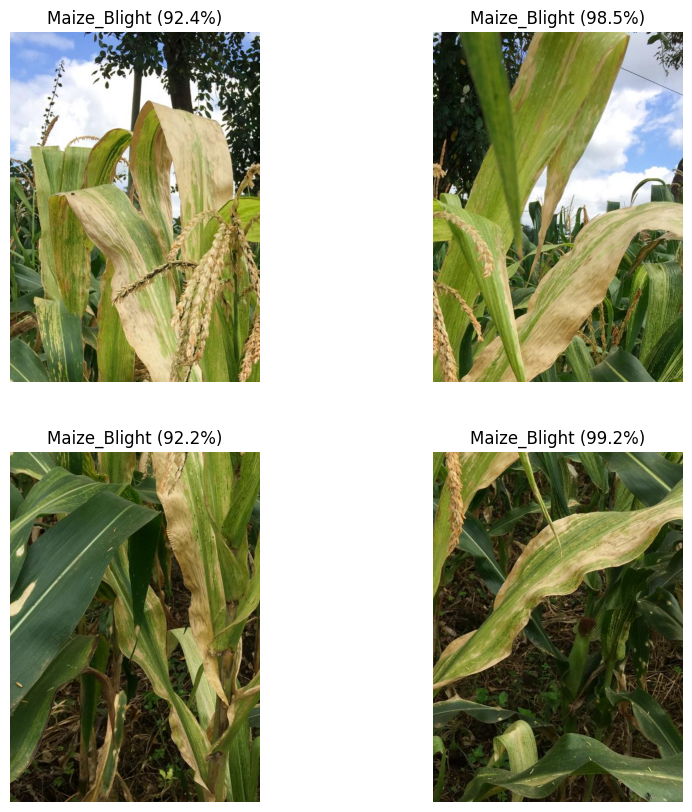


AGRO-ADVISOR REPORT FOR: VELLORE

DISEASE DETECTED: Maize_Blight
   ADVICE: Monitor closely. Disease pressure is moderate.


In [ ]:
import requests
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt
import json

model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
model = tf.keras.models.load_model(model_path)

class_indices_path = '/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json'
with open(class_indices_path, 'r') as f:
    class_indices = json.load(f)
class_names = {v: k for k, v in class_indices.items()}

def get_real_weather(city_name):
    print(f"Fetching live weather for {city_name}...")
    try:
        url = f"https://wttr.in/{city_name}?format=j1"
        response = requests.get(url)
        data = response.json()

        current = data['current_condition'][0]
        weather_report = {
            "temperature": int(current['temp_C']),
            "humidity": int(current['humidity']),
            "condition": current['weatherDesc'][0]['value'],
            "city": city_name
        }
        print(f"   Success! Temp: {weather_report['temperature']}C | Humidity: {weather_report['humidity']}% | Sky: {weather_report['condition']}")
        return weather_report
    except Exception as e:
        print(f"   Weather API Failed. Using default safe values. (Error: {e})")
        return {"temperature": 25, "humidity": 50, "condition": "Unknown", "city": city_name}

def predict_patch(img_patch):
    img_array = image.img_to_array(img_patch)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)
    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100
    return class_names[predicted_index], confidence

def get_expert_advice(vision_results, weather):
    print("\n" + "="*50)
    print(f"AGRO-ADVISOR REPORT FOR: {weather['city'].upper()}")
    print("="*50)

    advice = []
    found_weeds = [x for x in vision_results if "Weed" in x]
    found_diseases = [x for x in vision_results if "Maize" in x and "Healthy" not in x]

    if found_weeds:
        advice.append(f"WEED DETECTED: {', '.join(set(found_weeds))}")

        rain_keywords = ['Rain', 'Drizzle', 'Thunderstorm', 'Shower']
        is_raining = any(word in weather['condition'] for word in rain_keywords)

        if is_raining or weather['humidity'] > 85:
            advice.append("   DO NOT SPRAY: It is currently raining or very humid.")
            advice.append("      - Why: Rain will wash away the herbicide.")
            advice.append("      - Action: Wait 24 hours for dry weather.")
        elif weather['temperature'] > 32:
            advice.append("   CAUTION: High Temperature Alert (>32C).")
            advice.append("      - Why: Spraying herbicides in high heat can burn the corn leaves.")
            advice.append("      - Action: Spray early in the morning or evening.")
        else:
            advice.append("   GREEN LIGHT: Weather is optimal for spraying.")
            advice.append("      - Recommended: Application of Nicosulfuron.")

    if found_diseases:
        advice.append(f"\nDISEASE DETECTED: {', '.join(set(found_diseases))}")
        if weather['humidity'] > 70:
            advice.append("   CRITICAL ALERT: High Humidity Detected!")
            advice.append("      - Why: Fungus spreads rapidly in moist air.")
            advice.append("      - Action: Apply Fungicide immediately.")
        else:
            advice.append("   ADVICE: Monitor closely. Disease pressure is moderate.")

    if not found_weeds and not found_diseases:
        advice.append("CROP STATUS: Healthy. No actions needed.")

    return "\n".join(advice)

city = input("Step 1: Enter your Farm Location (City Name): ")
current_weather = get_real_weather(city)

print("\nStep 2: Upload Crop Photo")
uploaded = files.upload()

for filename in uploaded.keys():
    original_img = image.load_img(filename)
    width, height = original_img.size
    crops = {
        "Top-Left": original_img.crop((0, 0, width//2, height//2)),
        "Top-Right": original_img.crop((width//2, 0, width, height//2)),
        "Bottom-Left": original_img.crop((0, height//2, width//2, height)),
        "Bottom-Right": original_img.crop((width//2, height//2, width, height))
    }

    found_problems = []

    plt.figure(figsize=(10, 10))
    for i, (position, crop_img) in enumerate(crops.items()):
        crop_resized = crop_img.resize((224, 224))
        label, conf = predict_patch(crop_resized)
        if conf > 60: found_problems.append(label)

        plt.subplot(2, 2, i+1)
        plt.imshow(crop_img)
        plt.axis('off')
        plt.title(f"{label} ({conf:.1f}%)")
    plt.show()

    final_report = get_expert_advice(found_problems, current_weather)
    print(final_report)

In [ ]:
!pip install streamlit -q

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
import requests
from PIL import Image
import cv2
import openai
import json
import matplotlib.cm as cm

st.set_page_config(page_title="Agri-Smart Advisor", layout="wide")

@st.cache_resource
def load_model_and_indices():
    model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
    class_indices_path = "/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json"

    model = tf.keras.models.load_model(model_path)
    with open(class_indices_path, 'r') as f:
        class_indices = json.load(f)
    class_names = {v: k for k, v in class_indices.items()}
    return model, class_names

try:
    model, class_names = load_model_and_indices()
except Exception as e:
    st.error(f"Error loading model: {e}")
    st.stop()

def get_real_weather(city_name):
    try:
        url = f"https://wttr.in/{city_name}?format=j1"
        response = requests.get(url)
        data = response.json()
        current = data['current_condition'][0]
        return {
            "temperature": int(current['temp_C']),
            "humidity": int(current['humidity']),
            "condition": current['weatherDesc'][0]['value'],
            "city": city_name
        }
    except:
        return {"temperature": 25, "humidity": 50, "condition": "Unknown", "city": city_name}

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_activation", pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    return superimposed_img

def get_openai_advice(api_key, vision_results, weather):
    if not api_key:
        return "Please provide an OpenAI API Key to get detailed advice."

    client = openai.OpenAI(api_key=api_key)

    problems = ", ".join(vision_results) if vision_results else "None (Healthy)"

    prompt = f"""
    You are an expert agronomist.
    Current Situation:
    - Detected Crop Issues: {problems}
    - Local Weather: {weather['condition']}, {weather['temperature']}C, Humidity {weather['humidity']}%

    Task:
    1. Analyze the detected issues.
    2. Check if the current weather allows for spraying chemicals (warn if raining or too hot).
    3. Recommend a specific chemical treatment and an organic alternative.
    4. Keep it concise (under 150 words).
    """

    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[{"role": "user", "content": prompt}]
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"OpenAI Error: {e}"

st.title("Agri-Smart: Corn Doctor")
st.sidebar.header("Settings")

api_key = st.sidebar.text_input("OpenAI API Key", type="password")
city = st.sidebar.text_input("Farm Location (City)", value="Vellore")

uploaded_file = st.file_uploader("Upload Crop Image", type=["jpg", "png", "jpeg"])

if uploaded_file and city:
    original_img = Image.open(uploaded_file).convert("RGB")
    st.image(original_img, caption="Uploaded Image", use_column_width=True)

    with st.spinner("Analyzing..."):
        width, height = original_img.size
        crops = {
            "Top-Left": original_img.crop((0, 0, width//2, height//2)),
            "Top-Right": original_img.crop((width//2, 0, width, height//2)),
            "Bottom-Left": original_img.crop((0, height//2, width//2, height)),
            "Bottom-Right": original_img.crop((width//2, height//2, width, height))
        }

        found_problems = set()
        cols = st.columns(2)

        for i, (pos, crop_img) in enumerate(crops.items()):
            img_array = crop_img.resize((224, 224))
            img_array = tf.keras.preprocessing.image.img_to_array(img_array)
            img_batch = np.expand_dims(img_array, axis=0)
            preprocessed_img = tf.keras.applications.efficientnet_v2.preprocess_input(img_batch.copy())

            preds = model.predict(preprocessed_img, verbose=0)
            pred_index = np.argmax(preds)
            confidence = np.max(preds) * 100
            label = class_names[pred_index]

            if confidence > 60:
                found_problems.add(label)

                try:
                    heatmap = make_gradcam_heatmap(preprocessed_img, model, "top_activation", pred_index)
                    gradcam_img = overlay_heatmap(img_array, heatmap)

                    with cols[i % 2]:
                        st.image(gradcam_img, caption=f"{pos}: {label} ({confidence:.1f}%)")
                except Exception as e:
                    with cols[i % 2]:
                        st.image(crop_img, caption=f"{pos}: {label} ({confidence:.1f}%)")

        st.divider()

        weather = get_real_weather(city)
        st.subheader(f"Weather in {weather['city']}")
        w_col1, w_col2, w_col3 = st.columns(3)
        w_col1.metric("Temperature", f"{weather['temperature']} C")
        w_col2.metric("Condition", weather['condition'])
        w_col3.metric("Humidity", f"{weather['humidity']}%")

        st.subheader("AI Agronomist Diagnosis")

        vision_list = list(found_problems)
        if not vision_list:
            st.success("Crop looks healthy! No issues detected.")
        else:
            advice = get_openai_advice(api_key, vision_list, weather)
            st.write(advice)

Overwriting app.py


In [ ]:
# Run this to get your Password / IP
!wget -q -O - ipv4.icanhazip.com

35.229.61.32


In [ ]:
import time
import os
import re

os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")

if os.system("pip show streamlit > /dev/null 2>&1") != 0:
    os.system("pip install streamlit -q")

if not os.path.exists("cloudflared-linux-amd64"):
    os.system("wget -q -O cloudflared-linux-amd64 https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64")
    os.system("chmod +x cloudflared-linux-amd64")

os.system("streamlit run app.py > /dev/null 2>&1 &")

time.sleep(5)

os.system("rm -f tunnel.log")
os.system("nohup ./cloudflared-linux-amd64 tunnel --url http://localhost:8501 > tunnel.log 2>&1 &")

print("Waiting for link...")

for i in range(20):
    time.sleep(2)
    if os.path.exists("tunnel.log"):
        with open("tunnel.log", "r") as f:
            content = f.read()
            match = re.search(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', content)
            if match:
                print("Click this link: " + match.group(0))
                break
else:
    print("Could not generate link. Please try running the cell again.")

Waiting for link...
Click this link: https://lots-planners-syndicate-dayton.trycloudflare.com


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json

model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")

with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'r') as f:
    class_indices = json.load(f)
    class_names = {v: k for k, v in class_indices.items()}

print(f"Ready to detect: {list(class_names.values())}")

Mounted at /content/drive


Model loaded successfully!
Ready to detect: ['Maize_Blight', 'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Weed_Broadleaf', 'Weed_Grass']


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATA_DIR = "/content/drive/My Drive/Agri_Project_Data"
MODEL_PATH = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"

model = tf.keras.models.load_model(MODEL_PATH)

val_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input
)

validation_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Generating predictions...")
y_pred_probs = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

acc = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {acc * 100:.2f}%")

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

try:
    auc_score = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')
    print(f"AUC Score: {auc_score:.4f}")
except Exception as e:
    print(f"Could not calculate AUC: {e}")

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

Found 1580 images belonging to 6 classes.
Generating predictions...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 349s 7s/step
Accuracy: 97.28%
Classification Report:
                      precision    recall  f1-score   support

        Maize_Blight       0.90      0.93      0.91       229
   Maize_Common_Rust       0.96      1.00      0.98       261
Maize_Gray_Leaf_Spot       0.91      0.80      0.85       114
       Maize_Healthy       1.00      1.00      1.00       232
      Weed_Broadleaf       1.00      0.97      0.99        40
          Weed_Grass       1.00      1.00      1.00       704

            accuracy                           0.97      1580
           macro avg       0.96      0.95      0.95      1580
        weighted avg       0.97      0.97      0.97      1580

AUC Score: 0.9979
Confusion Matrix:
[[212   8   9   0   0   0]
 [  1 260   0   0   0   0]
 [ 20   2  91   1   0   0]
 [  1   0   0 231   0   0]
 [  1   0   0   0  39   0]
 [  0   0   0   0   0 704]]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json


model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")


with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'r') as f:
    class_indices = json.load(f)

    class_names = {v: k for k, v in class_indices.items()}

print(f"Ready to detect: {list(class_names.values())}")

Mounted at /content/drive


Model loaded successfully!
Ready to detect: ['Maize_Blight', 'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Weed_Broadleaf', 'Weed_Grass']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json


model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")


with open('/content/drive/My Drive/Agri_Project_Models/class_indices_v3.json', 'r') as f:
    class_indices = json.load(f)
    class_names = {v: k for k, v in class_indices.items()}

print(f"Ready to detect: {list(class_names.values())}")

Mounted at /content/drive


Model loaded successfully!
Ready to detect: ['Maize_Blight', 'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Weed_Broadleaf', 'Weed_Grass']


In [ ]:
import tensorflow as tf
import os

model_path = "/content/drive/My Drive/Agri_Project_Models/corn_real_world_model_v3.h5"


print("Loading model...")
model = tf.keras.models.load_model(model_path)

print("Converting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = "/content/drive/My Drive/Agri_Project_Models/corn_model.tflite"
with open(tflite_path, 'wb') as f:
  f.write(tflite_model)

print(f" Success! Your new model is saved at: {tflite_path}")

Loading model...


Converting to TFLite...
Saved artifact at '/tmp/tmpv54p4pyu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132649728267024: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132649728266832: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132649728262608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649728266256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649728267216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649728267984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649728268560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649728263184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649728266448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649728268368: TensorSpec(shape=(), dty

In [ ]:
import gdown
import os


MODEL_FILE_ID = '1_1PcQqUFFiK9tgpXwivM6J7OJShL18jk'
MODEL_FILENAME = 'corn_model.tflite'

if not os.path.exists(MODEL_FILENAME):
    print(f"⬇Downloading {MODEL_FILENAME}...")
    url = f'https://drive.google.com/uc?id={MODEL_FILE_ID}'
    gdown.download(url, MODEL_FILENAME, quiet=False, fuzzy=True)
    print(" Download Complete!")
else:
    print("Model already exists.")

⬇Downloading corn_model.tflite...


Downloading...
From: https://drive.google.com/uc?id=1_1PcQqUFFiK9tgpXwivM6J7OJShL18jk
To: /content/corn_model.tflite
100%|██████████| 24.7M/24.7M [00:00<00:00, 76.7MB/s]

 Download Complete!


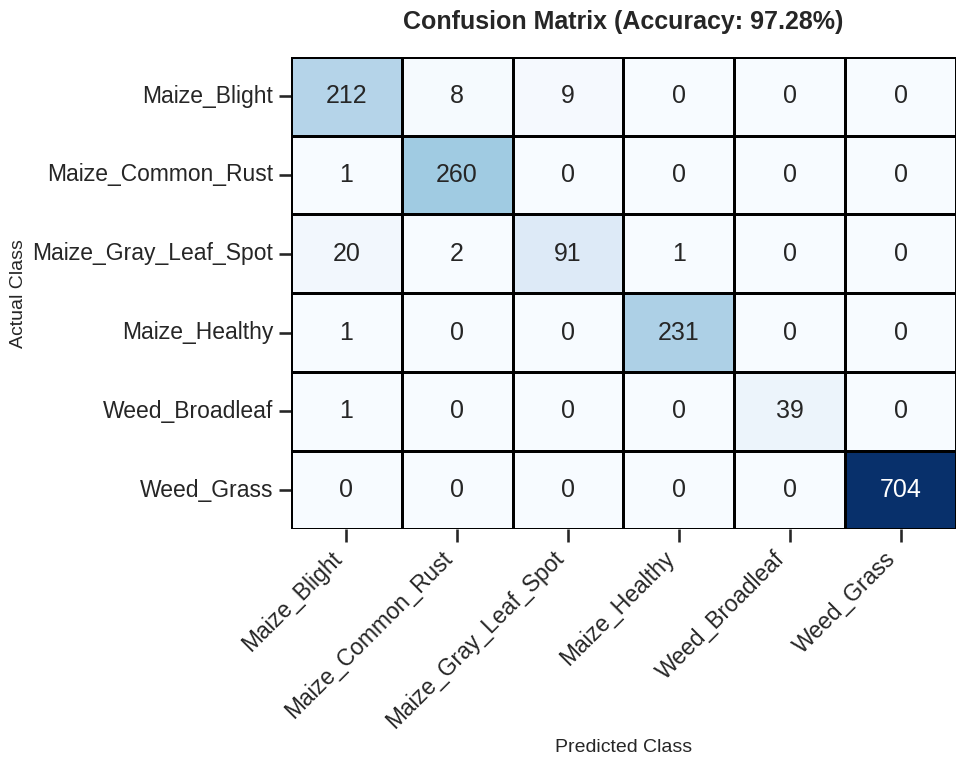

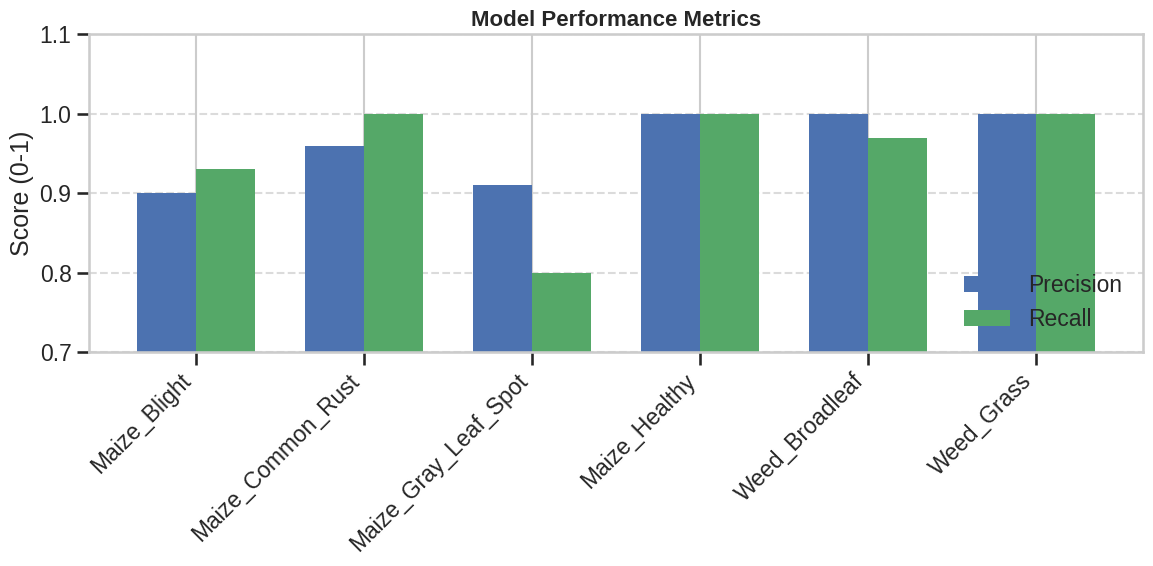

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

CLASS_NAMES = ['Maize_Blight', 'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot',
               'Maize_Healthy', 'Weed_Broadleaf', 'Weed_Grass']

cm_data = np.array([
    [212,   8,   9,   0,   0,   0],  # Blight
    [  1, 260,   0,   0,   0,   0],  # Common Rust
    [ 20,   2,  91,   1,   0,   0],  # Gray Leaf Spot
    [  1,   0,   0, 231,   0,   0],  # Healthy
    [  1,   0,   0,   0,  39,   0],  # Weed Broadleaf
    [  0,   0,   0,   0,   0, 704]   # Weed Grass
])


precision = [0.90, 0.96, 0.91, 1.00, 1.00, 1.00]
recall    = [0.93, 1.00, 0.80, 1.00, 0.97, 1.00]

plt.figure(figsize=(10, 8))
sns.set_context("talk")


sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=1, linecolor='black', cbar=False)

plt.title('Confusion Matrix (Accuracy: 97.28%)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Actual Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


x = np.arange(len(CLASS_NAMES))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, precision, width, label='Precision', color='#4c72b0')
plt.bar(x + width/2, recall, width, label='Recall', color='#55a868')

plt.ylabel('Score (0-1)')
plt.title('Model Performance Metrics', fontsize=16, fontweight='bold')
plt.xticks(x, CLASS_NAMES, rotation=45, ha='right')
plt.legend(loc='lower right')
plt.ylim(0.7, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

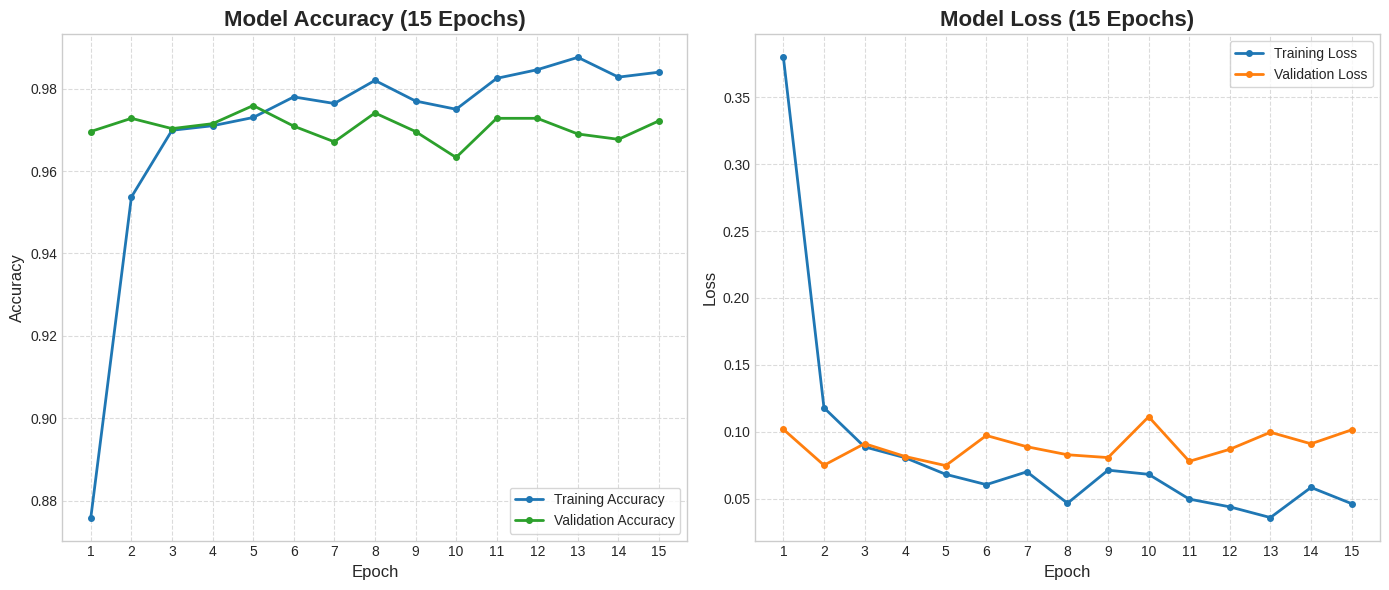

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

epochs = range(1, 16)

# Training Data (Blue Line)
acc = [0.8759, 0.9537, 0.9699, 0.9710, 0.9730, 0.9780, 0.9764, 0.9820,
       0.9770, 0.9750, 0.9825, 0.9846, 0.9876, 0.9828, 0.9840]

loss = [0.3797, 0.1180, 0.0888, 0.0807, 0.0683, 0.0606, 0.0702, 0.0467,
        0.0714, 0.0683, 0.0498, 0.0440, 0.0360, 0.0585, 0.0464]

# Validation Data (Orange/Green Line)
val_acc = [0.9696, 0.9728, 0.9703, 0.9715, 0.9759, 0.9709, 0.9671, 0.9741,
           0.9696, 0.9633, 0.9728, 0.9728, 0.9690, 0.9677, 0.9722]

val_loss = [0.1019, 0.0751, 0.0912, 0.0816, 0.0748, 0.0973, 0.0889, 0.0829,
            0.0808, 0.1113, 0.0780, 0.0870, 0.0997, 0.0911, 0.1015]

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, val_acc, label='Validation Accuracy', color='#2ca02c', linewidth=2, marker='o', markersize=4)
plt.title('Model Accuracy (15 Epochs)', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.xticks(epochs) # Show all epoch numbers 1-15
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='o', markersize=4)
plt.title('Model Loss (15 Epochs)', fontsize=16, fontweight='bold')
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()